### Butterworth bandpass filter to remove artifacts.

- [Filter design](https://www.youtube.com/watch?v=3yyp5JRqNXs)

In [22]:
# Load data

import pandas as pd

# # Define the file path (CDGR ventilator)
# file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/02-EVENTS/a-CDGR+AVEAA+SVU(58)_20240205/a-58_CDGR_39_1st/a-58_CDGR_39_1st_OSI/a-58_CDGR_39_1st_tw/a_58_CDGR_39_1st (1).csv"

# Define the file path (AVEAA ventilator)
file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/02-EVENTS/a-CDGR+AVEAA+SVU(58)_20240205/a-58_AVEAA_4_1st/a-58_AVEAA_4_1st_OSI/a-58_AVEAA_4_1st_tw/a_58_AVEAA_4_1st (1).csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Remove rows with at least one empty value across all columns
df = df.dropna()

# Convert 'Time' column to datetime format
df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S.%f')

In [ ]:
# # CDGR

# # # 4th minute from the 1st tumbling window.
# # start_time = '2023-10-04 17:34:21'
# # end_time = '2023-10-04 17:35:21'

# # # 6th minute from the 1st tumbling window.
# # start_time = '2023-10-04 17:36:21'
# # end_time = '2023-10-04 17:37:21'

# # # 8th minute from the 1st tumbling window.
# # start_time = '2023-10-04 17:38:21'
# # end_time = '2023-10-04 17:39:21'

# # 1st minute from the 2nd tumbling window.
# start_time = '2023-10-04 17:41:00'
# end_time = '2023-10-04 17:42:00'

# # Subset the data based on the time range
# subset_df = df[(df['Time'] >= start_time) & (df['Time'] <= end_time)]

# # Display the subset DataFrame
# print(subset_df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5859 entries, 59127 to 64985
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Relative Time (sec)  5859 non-null   float64       
 1   Time                 5859 non-null   datetime64[ns]
 2   CDGR - FiO₂          5859 non-null   int64         
 3   CDGR - Paw           5859 non-null   int64         
 4   CDGR - eVT           5859 non-null   float64       
 5   CDGR - Flow          5859 non-null   float64       
 6   CDGR - iPress Wave   5859 non-null   float64       
 7   GE - SpO2 1          5859 non-null   float64       
 8   OSI                  5859 non-null   float64       
 9   Tumbling_window      5859 non-null   int64         
dtypes: datetime64[ns](1), float64(6), int64(3)
memory usage: 503.5 KB
None


In [23]:
# AVEAA

# # 1st minute from the 1st tumbling window.
# start_time = '2023-12-18 20:14:35'
# end_time = '2023-12-18 20:15:35'

# # 3rd minute from the 1st tumbling window.
# start_time = '2023-12-18 20:16:35'
# end_time = '2023-12-18 20:17:35'

# # 5th minute from the 1st tumbling window.
# start_time = '2023-12-18 20:18:35'
# end_time = '2023-12-18 20:19:35'

# 1st minute from the 2nd tumbling window.
start_time = '2023-12-18 20:24:00'
end_time = '2023-12-18 20:25:00'

# Subset the data based on the time range
subset_df = df[(df['Time'] >= start_time) & (df['Time'] <= end_time)]

# Display the subset DataFrame
print(subset_df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6063 entries, 60490 to 66552
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Relative Time (sec)   6063 non-null   float64       
 1   Time                  6063 non-null   datetime64[ns]
 2   AVEA - PEEP           6063 non-null   float64       
 3   AVEA - eVT            6063 non-null   float64       
 4   AVEA - FiO₂           6063 non-null   float64       
 5   AVEA - PIP            6063 non-null   float64       
 6   AVEA - Paw            6063 non-null   float64       
 7   AVEA - Air Flow Wave  6063 non-null   float64       
 8   GE - SpO2 1           6063 non-null   float64       
 9   OSI                   6063 non-null   float64       
 10  Tumbling_window       6063 non-null   int64         
dtypes: datetime64[ns](1), float64(9), int64(1)
memory usage: 568.4 KB
None


In [13]:
# # CDGR pressure time domain demo

# import matplotlib.pyplot as plt

# # Plot the original waveform
# plt.figure(figsize=(10, 5))
# plt.plot(subset_df['CDGR - iPress Wave'])
# plt.xlabel('Time')
# plt.ylabel('CDGR - iPress Wave')
# plt.title('Original CDGR - iPress Waveform')
# plt.grid(True)
# plt.show()

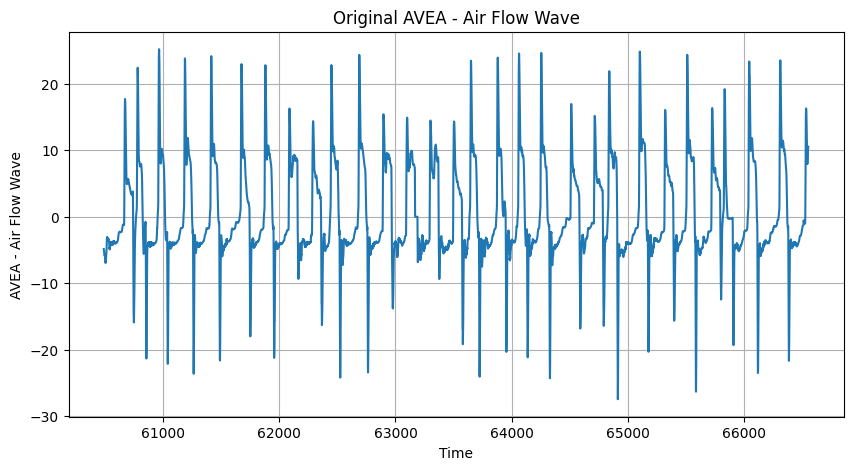

In [24]:
# # CDGR flow time domain demo
# import matplotlib.pyplot as plt

# # Plot the original waveform
# plt.figure(figsize=(10, 5))
# plt.plot(subset_df['CDGR - Flow'])
# plt.xlabel('Time')
# plt.ylabel('CDGR - Flow')
# plt.title('Original CDGR - Flow Waveform')
# plt.grid(True)
# plt.show()

# AVEAA flow time domain demo
import matplotlib.pyplot as plt

# Plot the original waveform
plt.figure(figsize=(10, 5))
plt.plot(subset_df['AVEA - Air Flow Wave'])
plt.xlabel('Time')
plt.ylabel('AVEA - Air Flow Wave')
plt.title('Original AVEA - Air Flow Wave')
plt.grid(True)
plt.show()

In [25]:
# Fourier transform

from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks
import numpy as np

# Perform Fourier transform
# x = subset_df["CDGR - iPress Wave"].values  # Input signal
# x = subset_df["CDGR - Flow"].values  # Input signal
x = subset_df["AVEA - Air Flow Wave"].values  # Input signal
# fs = 200  # Sampling frequency (CDGR pressure and Flow)
fs = 100  # Sampling frequency (AVEAA Flow)

# Number of samples in x
n = len(x)

# Compute the Fourier transform
yf = rfft(x)   # The amplitude
# yf = 20 * np.log10(yf)   # Convert amplitude to gain in decibels (dB)
xf = rfftfreq(n, 1 / fs)

In [20]:
# Apply Butterworth bandpass filter

from scipy.signal import butter, filtfilt

# Define the Butterworth filter parameters
# fs = 200  # Sampling frequency
fs = 100  # Sampling frequency
lowcut = 0.001  # Low cutoff frequency
# highcut = 99.99  # High cutoff frequency
highcut = 49.99  # High cutoff frequency
order = 3  # Filter order

# Design the Butterworth bandpass filter
nyquist = 0.5 * fs
low = lowcut / nyquist
high = highcut / nyquist
b, a = butter(order, [low, high], btype='band')

# Apply the Butterworth filter to the Fourier transformed data
filtered_yf = filtfilt(b, a, yf)

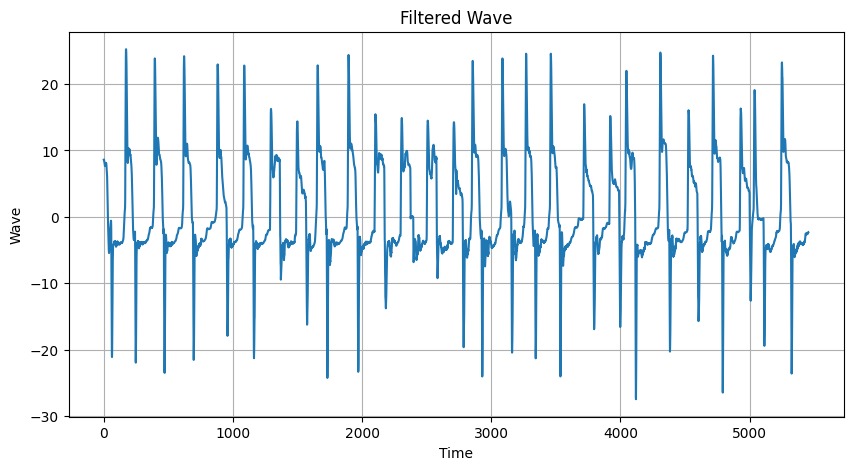

In [21]:
# Inverse Fourier transform

from scipy.fft import irfft
import matplotlib.pyplot as plt

# Perform inverse Fourier transform
inverted_signal = irfft(filtered_yf)

# Define the range of indices for the middle part of the plot
middle_start = int(len(inverted_signal) * 0.05)  # Start index of the middle part
middle_end = int(len(inverted_signal) * 0.95)    # End index of the middle part

# Plot both the real and imaginary parts of the inverted signal for the middle part
plt.figure(figsize=(10, 5))
plt.plot(inverted_signal[middle_start:middle_end])
plt.xlabel('Time')
plt.ylabel('Wave')
plt.title('Filtered Wave')
plt.grid(True)
plt.show()